In [1]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta

In [2]:
#Loading the physical dataset and matching the grid
directory_phy =  '/storage/shared/oceanparcels/input_data/MOi/'
phy_base_file =  directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc' 
phy_files_U = []
phy_files_V = []

starttime = datetime(2024,10,1)
endtime = datetime(2024,12,31)
dtime = timedelta(days=1)    #je stelt hier handmatig in wat de tijdsresolutie is van je data
time = starttime
phy_file_W = directory_phy + 'GLO12/psy4v3r1-daily_{vector:s}_{y:04d}-{m:02d}-{d:02d}.nc'.format(vector = 'W', y = time.year, m = time.month, d = time.day)
while(time < endtime):
    phy_files_U.append(phy_base_file.format(vector = 'U', y = time.year, m = time.month, d = time.day))
    phy_files_V.append(phy_base_file.format(vector = 'V', y = time.year, m = time.month, d = time.day))
    time+=dtime

#print(phy_files_U)

mesh_file_h = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_hgr.nc"   #Hiermee converteren we het grid!
mesh_file_z = directory_phy + "domain_ORCA0083-N006/PSY4V3R1_mesh_zgr.nc"
filenames_phy = {'U': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_U,
    }, 'V': {
        'lon': mesh_file_h,
        'lat': mesh_file_h,
       'depth':phy_file_W,
        'data': phy_files_V,
    }
}
variables_phy = {'U': 'vozocrtx',
                'V': 'vomecrty'}

c_grid_dimensions = {   'lat': 'gphif',
                        'lon': 'glamf',
                        'depth':'depthw',
                        'time': 'time_counter'}

dimensions_phy = {'U': c_grid_dimensions,
                 'V': c_grid_dimensions}

#Defining a range of indices to load as fieldset to reduce computational time
indices = {'lat': range(800,2000),
           'lon': range(2300,3500),
           'depth': range(0,20)
           }

#Creating fieldset
fieldset = parcels.FieldSet.from_nemo(filenames=filenames_phy,variables=variables_phy,dimensions=dimensions_phy, indices=indices)

(20, 1200, 1200)


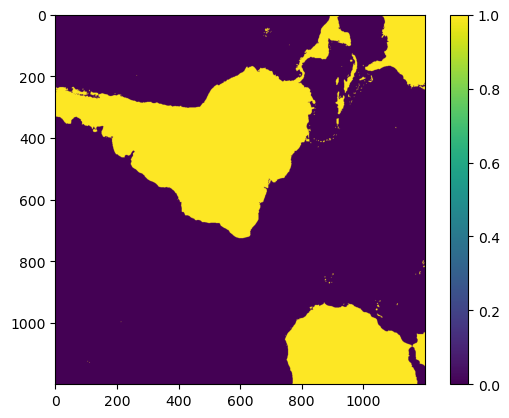

In [ ]:

fieldset.computeTimeChunk()
print(np.shape(fieldset.U.data[0,:,:]))

#plt.plot(fieldset.U.lat)

landmask = np.logical_or(np.ma.masked_equal(fieldset.U.data[0,:,:], 0.0), np.ma.masked_equal(fieldset.V.data[0,:,:], 0.0))

landmask2 = np.logical_or(fieldset.U.data[0,:,:]==0,fieldset.V.data[0,:,:]==0).astype(int)

plt.imshow(landmask2[0,:,:].T)
plt.colorbar()


In [ ]:
#Stokes drift data
add_stokes = True

avg_stokes = True
if avg_stokes:
    sarg_depth_extent = 1  

if add_stokes:
    directory_stokes = '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/'
    stokes_base_file =  directory_stokes + 'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_{y:04d}-{m:02d}-{d:02d}-{y:04d}-{m:02d}-{d:02d}.nc' 
    stokes_base_file =  directory_stokes + 'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_{y:04d}-{m:02d}-{d:02d}-{y:04d}-{m:02d}-{d:02d}.nc'
    
    stokes_files = []

    time = starttime
    while(time < endtime):
        stokes_files.append(stokes_base_file.format(y = time.year, m = time.month, d = time.day ))
        time+=dtime

    print(stokes_files)
    
    filenames_stokes = {'U_wave_Stokes': stokes_files,
                    'V_wave_Stokes': stokes_files,
                    'wave_Tp': stokes_files,
                    }
    variables_stokes = {'U_wave_Stokes': 'VSDX',        #Sea surface wave stokes drift x velocity
                    'V_wave_Stokes': 'VSDY',            #Sea surface wave stokes drift y velocity
                    'wave_Tp': 'VTPK'                   #Wave peak period
                    }
    dimensions_stokes = {'lat': 'latitude',
                        'lon': 'longitude',
                        'time': 'time'}
    
    #Defining a range of indices to load as fieldset to reduce computational time
    indices_stokes = {'lat': range(650,1750),
                       'lon': range(800,2500)
                     } 
    
    fieldset_stokes = parcels.FieldSet.from_netcdf(filenames=filenames_stokes, variables=variables_stokes, dimensions=dimensions_stokes, indices=indices_stokes)
    #Adding fields to initial fields
    fieldset.add_field(fieldset_stokes.U_wave_Stokes)
    fieldset.add_field(fieldset_stokes.V_wave_Stokes)

    #Only required if more advanced Stokes drift is implemented
    if avg_stokes:
        fieldset.add_field(fieldset_stokes.wave_Tp)
        fieldset.add_constant('G', 9.81)  # Gravitational constant [m s-1]
        fieldset.add_constant('depth_extent', sarg_depth_extent)  # depth extent of the sargassum [in m]



['/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_2024-10-01-2024-10-01.nc', '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_2024-10-02-2024-10-02.nc', '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_2024-10-03-2024-10-03.nc', '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-VTPK_180.00W-179.92E_80.00S-90.00N_2024-10-04-2024-10-04.nc', '/storage/shared/oceanparcels/input_data/CopernicusMarineService/GLOBAL_ANALYSISFORECAST_WAV_001_027/cmems_mod_glo_wav_anfc_0.083deg_PT3H-i_VSDX-VSDY-V

In [3]:
plt.plot(fieldset.U_wave_Stokes.lon)


AttributeError: 'FieldSet' object has no attribute 'U_wave_Stokes'

In [14]:
add_wind = True

if add_wind:

    ds = xr.open_mfdataset('/storage/shared/oceanparcels/input_data/ERA5/reanalysis-era5-single-level_wind10m_2024*.nc')

    filenames_wind = ds.sel(valid_time=slice(starttime, endtime))

    variables_wind = {'U_wind': 'u10', 
                      'V_wind':'v10'}

    dimensions_wind = {'lon':'longitude', 
                       'lat': 'latitude', 
                       'time': 'valid_time'}
    
    #Defining a range of indices to load as fieldset to reduce computational time
    indices_wind = {'lat': range(250,600),
                    'lon': range(750,1450)
                     }

    fieldset_wind= parcels.FieldSet.from_xarray_dataset(filenames_wind, variables_wind, dimensions_wind, indices=indices_wind, mesh='spherical')

    fieldset_wind.add_periodic_halo(zonal=True)

    windage_factor = 1

    fieldset_wind.U_wind.set_scaling_factor(windage_factor)
    fieldset_wind.V_wind.set_scaling_factor(windage_factor)

    fieldset_wind.U_wind.units = parcels.tools.converters.GeographicPolar()
    fieldset_wind.V_wind.units = parcels.tools.converters.Geographic()

    fieldset.add_field(fieldset_wind.U_wind)
    fieldset.add_field(fieldset_wind.V_wind)

#fieldset_wind


/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/parcels/grid.py:563: FieldSetWarning: Flipping lat data from North-South to South-North. Note that this may lead to wrong sign for meridional velocity, so tread very carefully
  super().__init__(lon, lat, time, time_origin, mesh)


In [ ]:
plt.plot(fieldset_wind.U_wind.lon, label='U wind lon')
#plt.plot(fieldset.U_wave_Stokes.lon, label = 'U lon')


In [ ]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset_stokes.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset_stokes.U_wave_Stokes.lon, fieldset_stokes.U_wave_Stokes.lat, fieldset_stokes.U_wave_Stokes.data[0, :,:], 
                    vmin=-0.25, vmax=0.5 , transform=ccrs.PlateCarree())
#pplot = ax.plot(pset.lon, pset.lat, "ko", color='red')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal Stokes drift velocity plot at {starttime}')
#ax.set_extent([-90,0,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Velocity [m/s]')
plt.show()

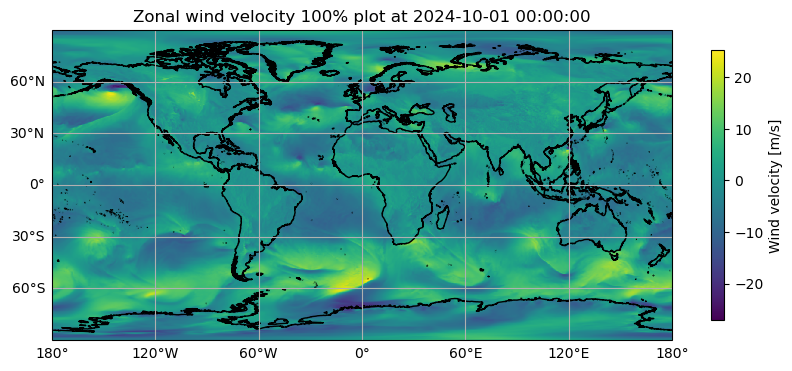

In [15]:
#By using fieldset.computeTimeChunk(), we load the first time frame of the fieldset.
fieldset_wind.computeTimeChunk()

#Plotting velocity field of first timestep
fig1 = plt.figure(figsize = (10,7))
ax = plt.axes(projection=ccrs.PlateCarree())
vplot = ax.pcolormesh(fieldset_wind.U_wind.grid.lon, fieldset_wind.U_wind.grid.lat, fieldset_wind.U_wind.data[0, :,:], 
                       transform=ccrs.PlateCarree())
#pplot = ax.plot(pset.lon, pset.lat, "ko", color='red')
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Zonal wind velocity {round(windage_factor*100, 2)}% plot at {starttime}')
#ax.set_extent([-90,0,-10,25])
cbar = fig1.colorbar(vplot, ax=ax, shrink = 0.5)
cbar.set_label('Wind velocity [m/s]')
plt.show()

In [ ]:
#Defining particle set that we can advect on fieldset

nparticles = 9    #how many particles will be advected

pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,  # the fields on which the particles are advected
    pclass=parcels.JITParticle,  # the type of particles (JITParticle or ScipyParticle)
    lon=[-40, -40, -40, -43, -43, -43 , -46, -46, -46], # a vector of release longitudes
    lat=[2,  5,  8, 2, 5,  8, 2, 5,  8],                # a vector of release latitudes
    depth=[0] * nparticles                             # a vector of release depths
)

output_file = pset.ParticleFile(
    name="/storage/shared/oceanparcels/output_data/data_Elena/Test5_Advected_Particles_extra_kernels.zarr",  # the file name
    outputdt=timedelta(hours=1),          # the time step of the outputs
    chunks = (nparticles, 50))              #per hoeveel tijdstappen je data wordt opgeslagen

print(output_file)

In [ ]:
#Defining all kernels

import custom_kernels as ck

#All kernels in a list
kernels = [ parcels.AdvectionRK4 ]

if add_stokes:
    if avg_stokes:
        kernels+= [ck.avg_Stokes_drift]
    else:
        kernels+= [ck.direct_Stokes_drift]
if add_wind:
    kernels+= [ck.wind_drag]

#Execute
pset.execute(
    kernels,        # the kernels (which define how particles move)
    runtime=timedelta(days=10),  # the total length of the run
    dt=timedelta(minutes=5),    # the timestep of the kernel
    output_file=output_file,
)

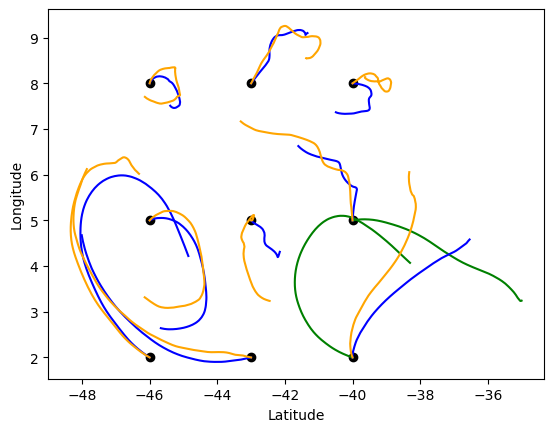

In [3]:
ds1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Test2_Advected_Particles.zarr")
ds2 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Test4_Advected_Particles_extra_kernels.zarr")
ds3 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/Test5_Advected_Particles_extra_kernels.zarr")


plt.plot(ds1.lon.T, ds1.lat.T, "-" , color='green' )
plt.plot(ds2.lon.T, ds2.lat.T,   '-' , color = 'blue')
plt.plot(ds3.lon.T, ds3.lat.T,   '-' , color = 'orange')
plt.scatter(ds3.lon.T[0], ds3.lat.T[0], color = 'black')

plt.xlabel("Latitude")
plt.ylabel("Longitude")
#plt.legend()
plt.show()


In [ ]:
hoi = list(np.zeros((9,), dtype=np.int8))

print(hoi)

hi = [0] * 9

print(hi)